## Laufzeiten der Sortieralgorithmen

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
import random
import time 

#### Sortieralgorithmen mit Laufzeit O(n*log(n))

In [15]:
def merge(a, b):
    i = j = 0
    c=[]
    while i < len(a) and j < len(b):
        if a[i] < b[j]:
            c.append(a[i])
            i+=1
        else:
            c.append(b[j])
            j+=1
    if i == len(a):
        c.extend(b[j:])
    else:
        c.extend(a[i:])
    return c

def merge_sort(a):
    if len(a) <= 1: return a
    halb = len(a)//2
    b = a[:halb]
    c = a[halb:]
    return merge(merge_sort(b),merge_sort(c))

In [16]:
def quick_sort(a, unten = 0, oben = None):
    if oben == None: oben = len(a)-1
    i , j = unten, oben
    mitte = (unten + oben) // 2
    pivot = a[mitte]
    while i <= j:
        while a[i] < pivot: i+=1
        while a[j] > pivot: j-=1
        if i <= j:
            a[i], a[j] = a[j], a[i]
            i+=1
            j-=1
    if unten < j: quick_sort(a,unten,j)
    if i < oben: quick_sort(a,i,oben)

In [17]:
def sift(a, start , end):
    i = start
    x = a[start]
    j = 2 * i + 1
    if j < end and a[j+1] < a[j]:
        j+=1
    while j <= end and a[j] < x:
        a[i] = a[j]
        i = j
        j = j * 2 + 1
        if j < end and a[j+1] < a[j]:
            j+=1
    a[i] = x

def heap_sort(a):
    n = len(a)
    for k in range ((n-2)//2,-1,-1):
        sift(a,k,n-1)
    for k in range(n-1,0,-1):
        a[0],a[k]=a[k],a[0]
        sift(a,0,k-1)

In [23]:
N = 100               # Anzahl zu sortierender Elemente in Tausend
anzahl_versuche = 5    # Anzahl Sortiervorgänge
summe = 0
for i in range(anzahl_versuche):
    a = [random.randint(-N*1000,N*1000) for _  in range(N*1000)] 
    start = time.perf_counter()
    merge_sort(a)
    end = time.perf_counter()
    summe = summe + (end-start)

print(f'{summe/anzahl_versuche:.3f}')


0.300


In [24]:
anzahl = [100,200,400,800,1600,3200]
merge = [0.300, 0.719, 1.422, 3.110, 6.718, 14.387]
quick = [0.280, 0.672, 1.499, 2.631, 4.774, 9.881]
heap=[0.629, 1.165, 2.642, 4.881, 9.244, 18.528]
tim=[0.030, 0.072, 0.193, 0.456, 0.804, 1.610]

In [25]:
def n_log_n_model(n, a, b):
    return a * n * np.log(n) + b

In [26]:
params, _ = curve_fit(n_log_n_model, anzahl, merge)
a_merge, b_merge = params
print(f"merge: T(n) ≈ {a_merge:.8f} * n * log(n) + {b_merge:.8f}") 
params, _ = curve_fit(n_log_n_model, anzahl, quick)
a_quick, b_quick = params
print(f"quick: T(n) ≈ {a_quick:.8f} * n * log(n) + {b_quick:.8f}") 
params, _ = curve_fit(n_log_n_model, anzahl, heap)
a_heap, b_heap = params
print(f"heap:  T(n) ≈ {a_heap:.8f} * n * log(n) + {b_heap:.8f}") 
params, _ = curve_fit(n_log_n_model, anzahl, tim)
a_tim, b_tim = params
print(f"tim:   T(n) ≈ {a_tim:.8f} * n * log(n) + {b_tim:.8f}") 

merge: T(n) ≈ 0.00055408 * n * log(n) + 0.11203107
quick: T(n) ≈ 0.00036968 * n * log(n) + 0.40006910
heap:  T(n) ≈ 0.00069759 * n * log(n) + 0.72918022
tim:   T(n) ≈ 0.00006167 * n * log(n) + 0.04547645


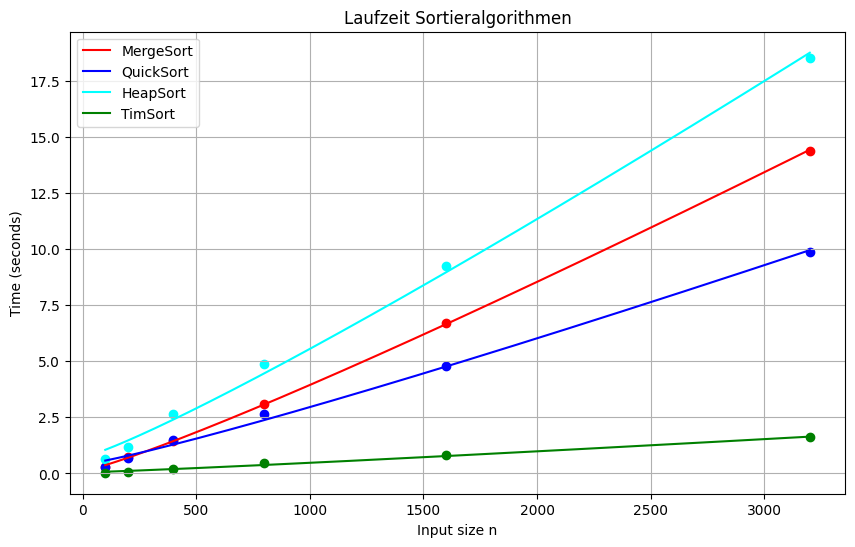

In [27]:
plt.figure(figsize=(10, 6))
plt.scatter(anzahl, merge, color='red')
plt.scatter(anzahl, quick, color='blue')
plt.scatter(anzahl, heap, color='cyan')
plt.scatter(anzahl, tim, color='green')
n_fine = np.linspace(min(anzahl), max(anzahl), 500)
plt.plot(n_fine, n_log_n_model(n_fine, a_merge, b_merge), label="MergeSort", color='red')
plt.plot(n_fine, n_log_n_model(n_fine, a_quick, b_quick), label="QuickSort", color='blue')
plt.plot(n_fine, n_log_n_model(n_fine, a_heap, b_heap), label="HeapSort", color='cyan')
plt.plot(n_fine, n_log_n_model(n_fine, a_tim, b_tim), label="TimSort", color='green')
plt.xlabel("Input size n")
plt.ylabel("Time (seconds)")
plt.title("Laufzeit Sortieralgorithmen")
plt.legend()
plt.grid(True)
plt.show()